In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Exploratory Data Analysis

In [101]:
df = pd.read_csv('security_events.csv', parse_dates=['timestamp'])
df.head()

,event_id,timestamp,log_source,user_id,department,privilege_level,user_home_country,hostname,source_ip,geo_country,auth_success,event_type,file_size_mb,destination_ip,bytes_sent,bytes_received
0,1,2025-05-01 00:00:00,network,U0088,IT,admin,NL,BACKUP-SVC-01,NaN,NaN,NaN,NaN,NaN,10.0.0.10,1.008000e+03,764.0
1,2,2025-05-01 01:00:00,network,U0088,IT,admin,NL,BACKUP-SVC-01,NaN,NaN,NaN,NaN,NaN,10.0.0.10,9.450000e+02,724.0
2,3,2025-05-01 01:00:00,network,U0088,IT,admin,NL,BACKUP-SVC-01,NaN,NaN,NaN,NaN,NaN,10.0.50.10,6.136724e+09,50000.0
3,4,2025-05-01 01:00:00,auth,U0088,IT,admin,NL,NaN,145.53.12.20,NL,1.0,NaN,NaN,NaN,NaN,NaN
4,5,2025-05-01 02:00:00,network,U0088,IT,admin,NL,BACKUP-SVC-01,NaN,NaN,NaN,NaN,NaN,10.0.0.10,8.570000e+02,722.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134975 entries, 0 to 134974
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   event_id           134975 non-null  int64  
 1   timestamp          134975 non-null  object 
 2   log_source         134975 non-null  object 
 3   user_id            134975 non-null  object 
 4   department         134855 non-null  object 
 5   privilege_level    133973 non-null  object 
 6   user_home_country  134855 non-null  object 
 7   hostname           117906 non-null  object 
 8   source_ip          16557 non-null   object 
 9   geo_country        16814 non-null   object 
 10  auth_success       17069 non-null   float64
 11  event_type         27950 non-null   object 
 12  file_size_mb       12755 non-null   float64
 13  destination_ip     89956 non-null   object 
 14  bytes_sent         89956 non-null   float64
 15  bytes_received     89956 non-null   float64
dtypes:

In [13]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_percent = missing_percent.round(2)  
print(pd.DataFrame({'Пропуски': missing, '%': missing_percent}).sort_values('%', ascending=False))

                   Пропуски      %
file_size_mb         122220  90.55
source_ip            118418  87.73
geo_country          118161  87.54
auth_success         117906  87.35
event_type           107025  79.29
destination_ip        45019  33.35
bytes_sent            45019  33.35
bytes_received        45019  33.35
hostname              17069  12.65
privilege_level        1002   0.74
department              120   0.09
user_home_country       120   0.09
event_id                  0   0.00
timestamp                 0   0.00
log_source                0   0.00
user_id                   0   0.00


### В более чем 8ми столбцах есть пропуски более 30% содержимого, но они все еще могут быть полезны для обнаружения аномалий

In [14]:
duplicates = df.duplicated().sum()
duplicates_event_id = df['event_id'].duplicated().sum()
print(f"Полных дубликатов: {duplicates}")
print(f"Дубликатов event_id: {duplicates_event_id}")

Полных дубликатов: 0
Дубликатов event_id: 0


### Логи по event_id уникальны

# 1.1. Распределения данных по столбцам

## 1.1.1. Источник логов

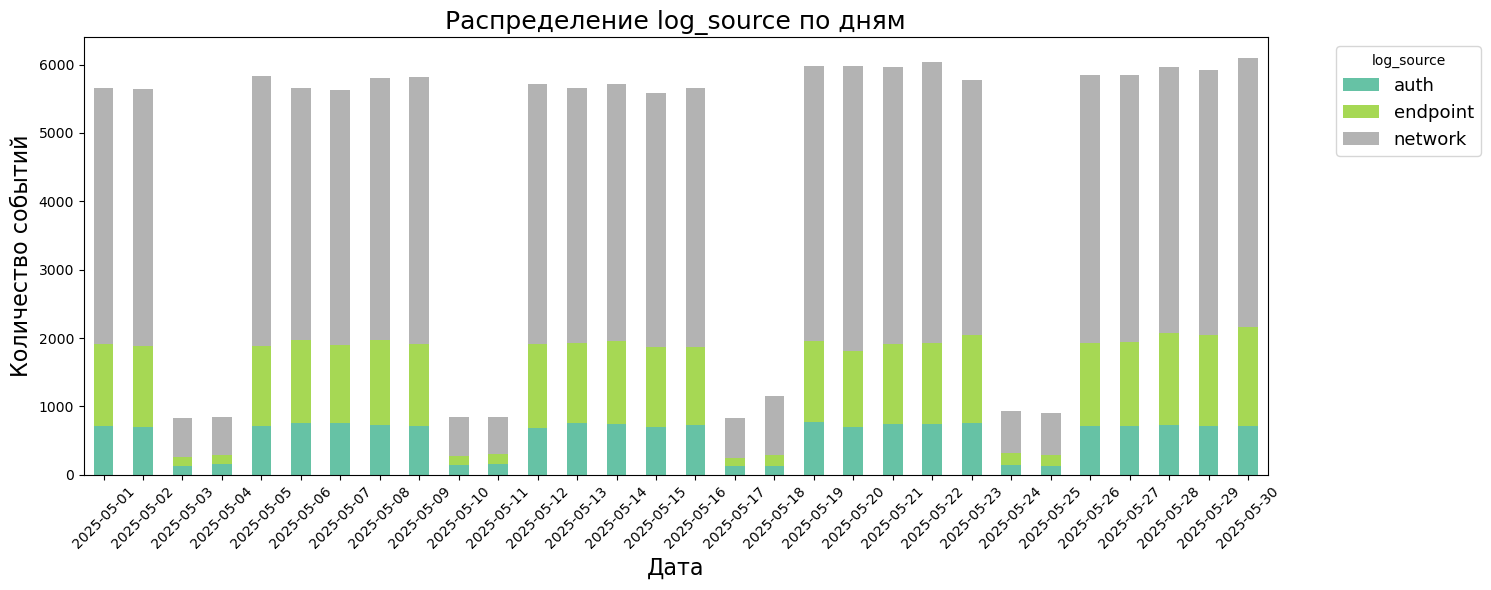

In [27]:
# Группируем по дате и источнику логов
daily_source = df.groupby([df['timestamp'].dt.date, 'log_source']).size().unstack(fill_value=0)

# Строим столбчатую диаграмму с накоплением
daily_source.plot(kind='bar', stacked=True, figsize=(15, 6), colormap='Set2')
plt.title('Распределение log_source по дням', fontsize=18)
plt.xlabel('Дата', fontsize=16)
plt.ylabel('Количество событий', fontsize=16)
plt.legend(title='log_source', bbox_to_anchor=(1.05, 1), loc='upper left' , fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Первое, на что хотелось посмотреть - источник события, а точнее его распределение по дням. Т.к. например резкое смещение баланса в сторону аутентификации в какой-либо день может свидетельствовать о попытке взлома. Однако соотношение долей различных источников среди данных 30 дней довольно равномерное. Нужно отметить, что в 8/30 дней наблюдается резкое снижение количества событий, что скорее всего связано с 5-дневной рабочей неделей :)

## 1.1.2. ID пользователя

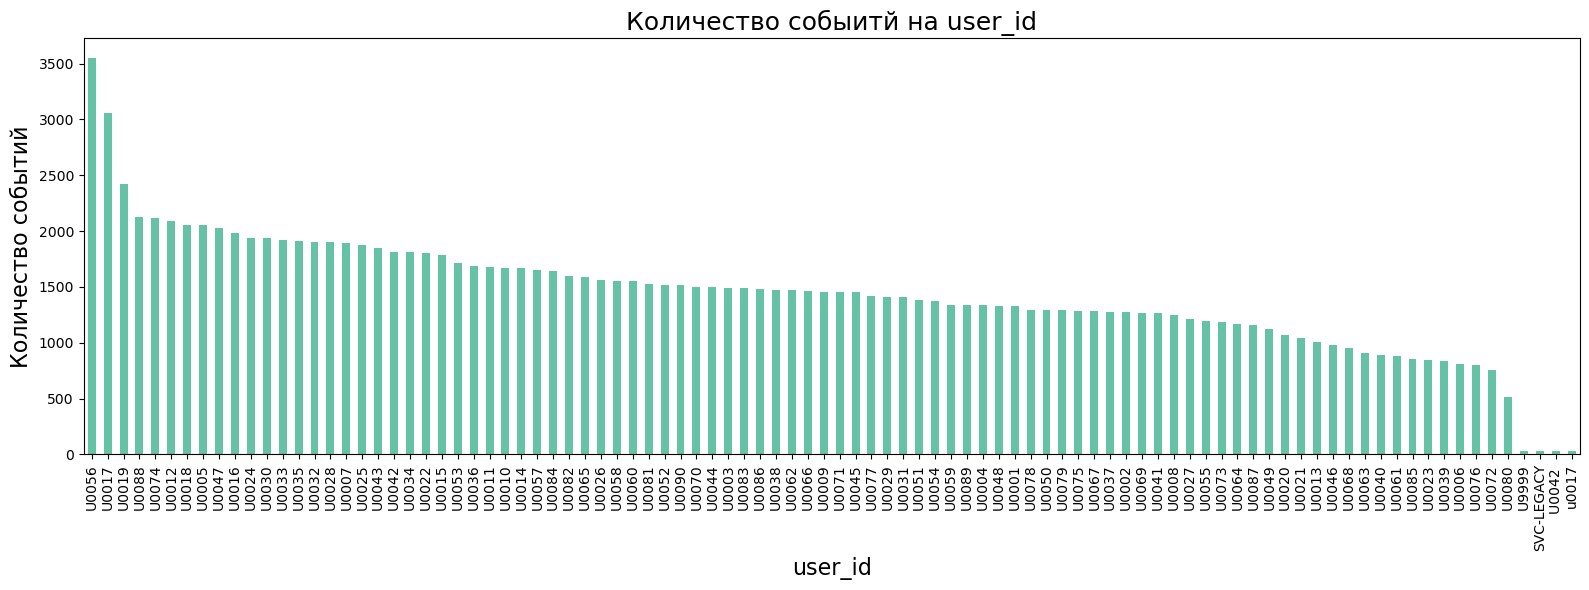

In [38]:
df['user_id'].value_counts().plot(kind='bar', figsize=(16, 6), colormap='Set2')
plt.title('Количество собыитй на user_id', fontsize=18)
plt.xlabel('user_id', fontsize=16)
plt.ylabel('Количество событий', fontsize=16)
plt.tight_layout()
plt.show()

### У пользователей с user_id U0056, U0017, U0019 много событий по сравнению с другими пользователями. Чтобы понимать, насколько это количество аномально, я решила сравнить кол-во событий этих пользователей с кол-вом событий других людей в их отделе.

In [81]:
user_activity = df.groupby('user_id').size().reset_index(name='event_count')
user_activity = user_activity.sort_values('event_count', ascending=False)

user_departments = df.groupby('user_id')['department'].first().reset_index()
user_activity_with_dept = user_activity.merge(user_departments, on='user_id', how='left')

In [82]:
dept_stats = user_activity_with_dept.groupby('department')['event_count'].agg(['count','mean','std','max','min']).reset_index()

user_activity_with_dept = user_activity_with_dept.merge(
    dept_stats[['department', 'mean', 'std']], 
    on='department', 
    how='left'
)

# Вычисляем отклонение от среднего (в стандартных отклонениях)
user_activity_with_dept['z_score'] = (user_activity_with_dept['event_count'] - user_activity_with_dept['mean']) / user_activity_with_dept['std']

# Находим аномалии (z-score > 2 означает "выше нормы")
anomalies = user_activity_with_dept[user_activity_with_dept['z_score'] > 2].sort_values('z_score', ascending=False)

print("Пользователи с аномально выскокй активностью для своего отдела:")
print(anomalies[['user_id', 'department', 'event_count', 'mean', 'z_score']])

Пользователи с аномально выскокй активностью для своего отдела:
  user_id   department  event_count         mean   z_score
1   U0017  Engineering         3059  1692.687500  2.618343
0   U0056          R&D         3548  1758.555556  2.540866
2   U0019      Support         2424  1356.142857  2.186711


### Таким образом, даже для своих отделов у данных пользователей наблюдается повышенная активность.

## 1.1.3. Отдел (department)

/tmp/ipykernel_1800548/1730752578.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_activity_with_dept, x='department', y='event_count', palette='Set3')


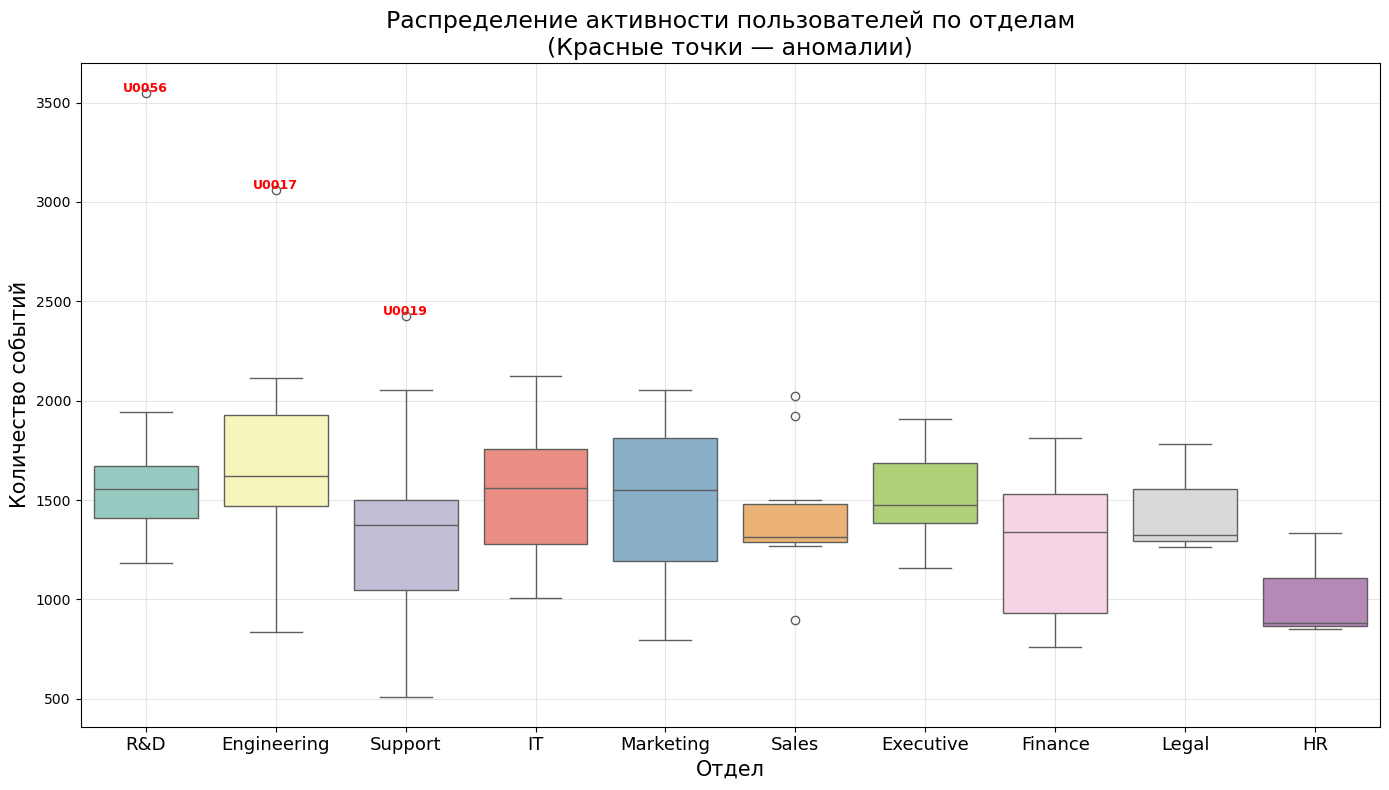

In [89]:
plt.figure(figsize=(14, 8))

sns.boxplot(data=user_activity_with_dept, x='department', y='event_count', palette='Set3')

# Аномалии
for idx, row in anomalies.iterrows():
    plt.text(row['department'], row['event_count'] + 5, row['user_id'], 
             fontsize=9, ha='center', color='red', fontweight='bold')

plt.title('Распределение активности пользователей по отделам\n(Красные точки — аномалии)', fontsize=17)
plt.xlabel('Отдел', fontsize=15)
plt.ylabel('Количество событий', fontsize=15)
plt.xticks(fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [131]:
def plot_user_activity_per_day(user_id):

    df[df['user_id']==user_id].groupby([df['timestamp'].dt.date]).size().plot(kind='bar', colormap='Set2')

    plt.title(f'Распределение активности {user_id} по дням', fontsize=15)
    plt.xlabel('Дата', fontsize=13)
    plt.ylabel('Количество событий', fontsize=13)
    plt.xticks(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

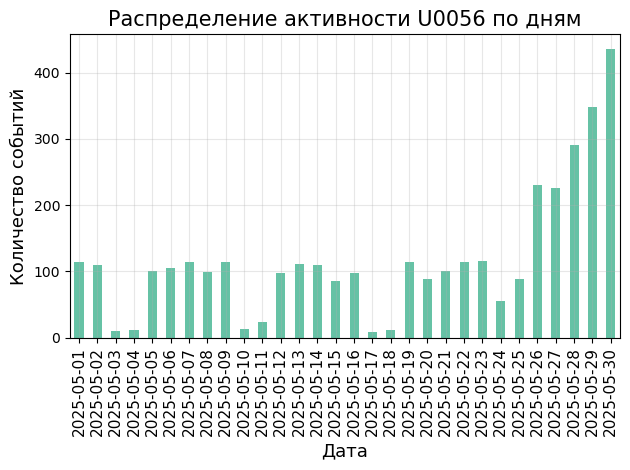

In [132]:
plot_user_activity_per_day('U0056')

### Рост активности у пользователя U0056 может быть связан с концом месяца - отчетным периодом

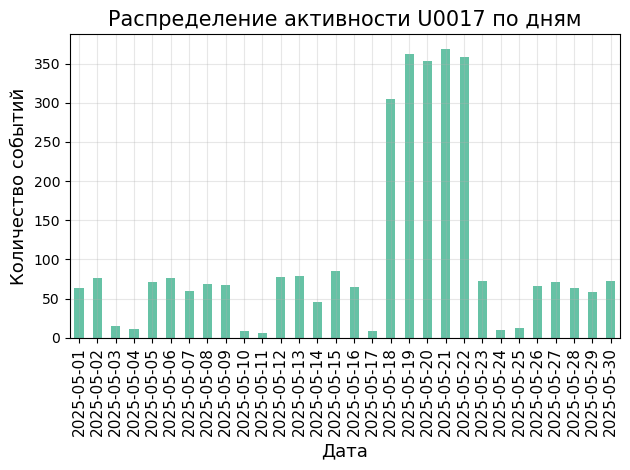

In [133]:
plot_user_activity_per_day('U0017')

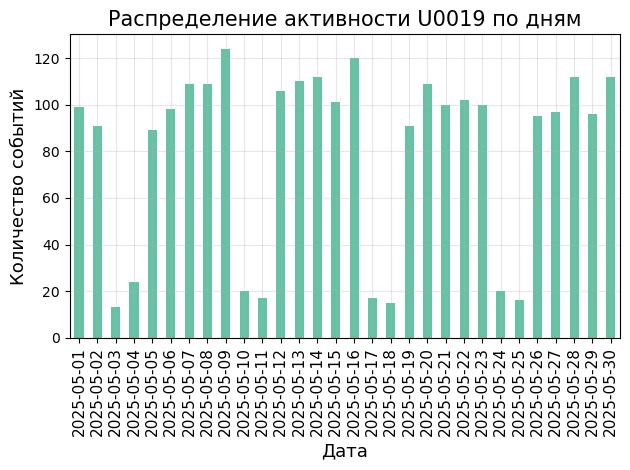

In [134]:
plot_user_activity_per_day('U0019')

### У пользователя U0019 из отдела "Support" активность высокая, но постоянная, в отличие от U0017 и U0056

## 1.1.4. По уровням привелегий

<Axes: ylabel='count'>

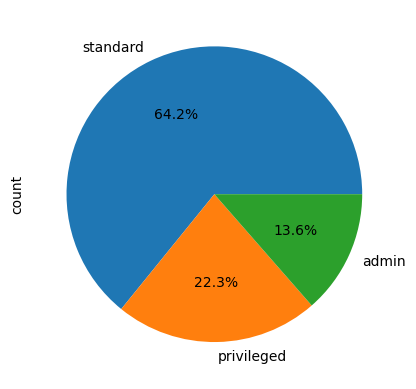

In [125]:
df['privilege_level'].value_counts().plot(kind='pie', autopct='%1.1f%%')

### Стандартный уровень привелегий составляет большую часть пользователей

## 1.1.5. Объем трафика

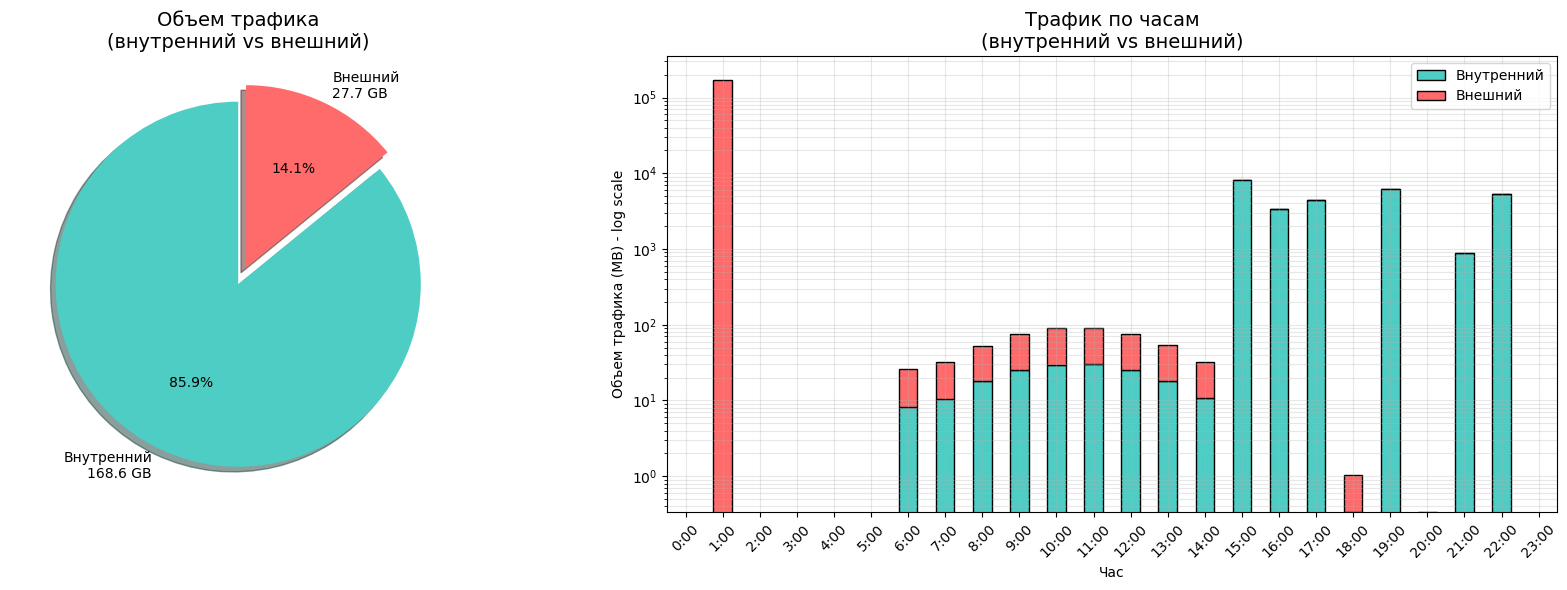

In [20]:
network_df = df[df['log_source'] == 'network'].copy()

# внутренний/внешний трафик
internal_prefixes = ('10.',)
network_df['is_internal'] = network_df['destination_ip'].astype(str).str.startswith(internal_prefixes)
network_df['traffic_type'] = network_df['is_internal'].map({True: 'Внутренний', False: 'Внешний'})

total_bytes = network_df['bytes_sent'].sum()
internal_bytes = network_df[network_df['is_internal']]['bytes_sent'].sum()
external_bytes = network_df[~network_df['is_internal']]['bytes_sent'].sum()

# Распределение внутреннего vs внешнего трафика
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sizes = [internal_bytes, external_bytes]
labels = [f'Внутренний\n{internal_bytes/1024/1024/1024:.1f} GB', 
          f'Внешний\n{external_bytes/1024/1024/1024:.1f} GB']
colors = ['#4ecdc4', '#ff6b6b']
explode = (0, 0.1)

axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', 
            startangle=90, explode=explode, shadow=True)
axes[0].set_title('Объем трафика\n(внутренний vs внешний)', fontsize=14)

# Трафик по часам (внутренний vs внешний)
network_df['hour'] = network_df['timestamp'].dt.hour
hourly_traffic = network_df.groupby(['hour', 'traffic_type'])['bytes_sent'].sum().unstack(fill_value=0)
hourly_traffic_mb = hourly_traffic / (1024 * 1024)

hourly_traffic_mb_log = hourly_traffic_mb + 0.001

hourly_traffic_mb_log.plot(kind='bar', stacked=True, ax=axes[1], 
                           color=['#4ecdc4', '#ff6b6b'], edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_title('Трафик по часам\n(внутренний vs внешний)', fontsize=14)
axes[1].set_xlabel('Час')
axes[1].set_ylabel('Объем трафика (MB) - log scale')
axes[1].legend(['Внутренний', 'Внешний'])
axes[1].grid(True, alpha=0.3, which='both')  
axes[1].set_xticklabels([f'{h}:00' for h in range(24)], rotation=45)

plt.tight_layout()
plt.show()

# 1.2. Временной анализ

## 1.2.1 Распределние по часам рабочего дня

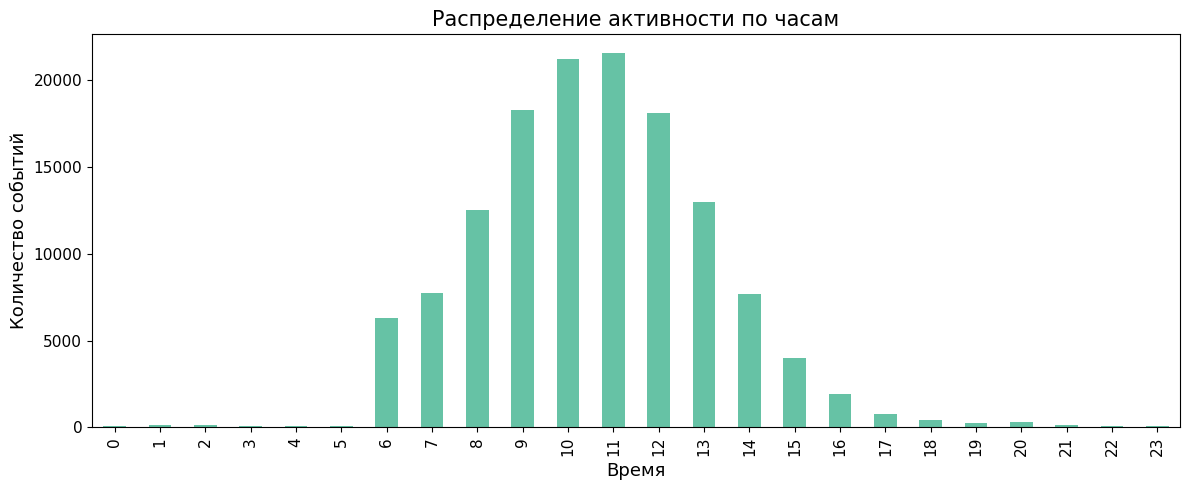

In [140]:
hourly_events = df.groupby(df['timestamp'].dt.hour).size()
hourly_events.plot(kind='bar', figsize=(12, 5), colormap='Set2')

plt.title(f'Распределение активности по часам', fontsize=15)
plt.xlabel('Время', fontsize=13)
plt.ylabel('Количество событий', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

### Пик активности с 6 до 16

## 1.2.2. Распределение по дням недели

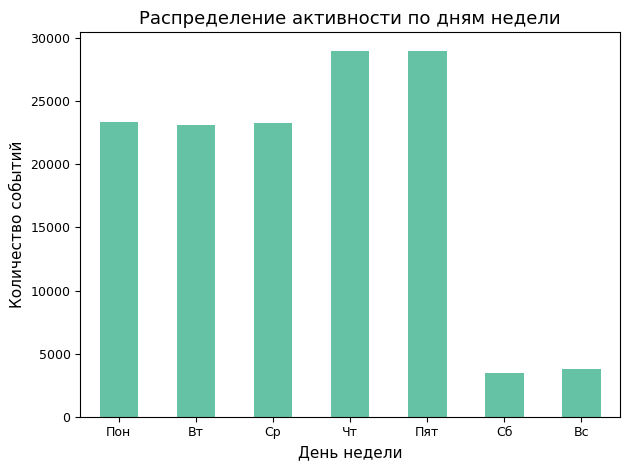

In [141]:
df['day_of_week'] = df['timestamp'].dt.dayofweek
df.groupby('day_of_week').size().plot(kind='bar', colormap='Set2')
days = ('Пон', 'Вт', 'Ср', 'Чт', 'Пят', 'Сб', 'Вс')

plt.title(f'Распределение активности по дням недели', fontsize=13)
plt.xlabel('День недели', fontsize=11)
plt.ylabel('Количество событий', fontsize=11)
plt.xticks(ticks=range(7), labels=days, fontsize=9, rotation=0)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# 1.3. Анализ конкретных источников

## 1.3.1. auth

<Axes: ylabel='count'>

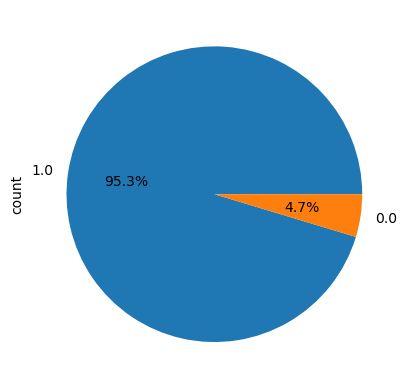

In [146]:
auth_df = df[df['log_source'] == 'auth']

# Соотношение успешных/неудачных
auth_df['auth_success'].value_counts().plot(kind='pie', autopct='%1.1f%%')

In [147]:
# Пользователи с аномально большим количеством неудачных входов
failed_auth = auth_df[auth_df['auth_success'] == 0]
failed_by_user = failed_auth['user_id'].value_counts().head(5)
print(failed_by_user)

user_id
U0042    39
U0033    19
U0048    19
U0038    18
U0014    18
Name: count, dtype: int64


## 1.3.2. endpoint

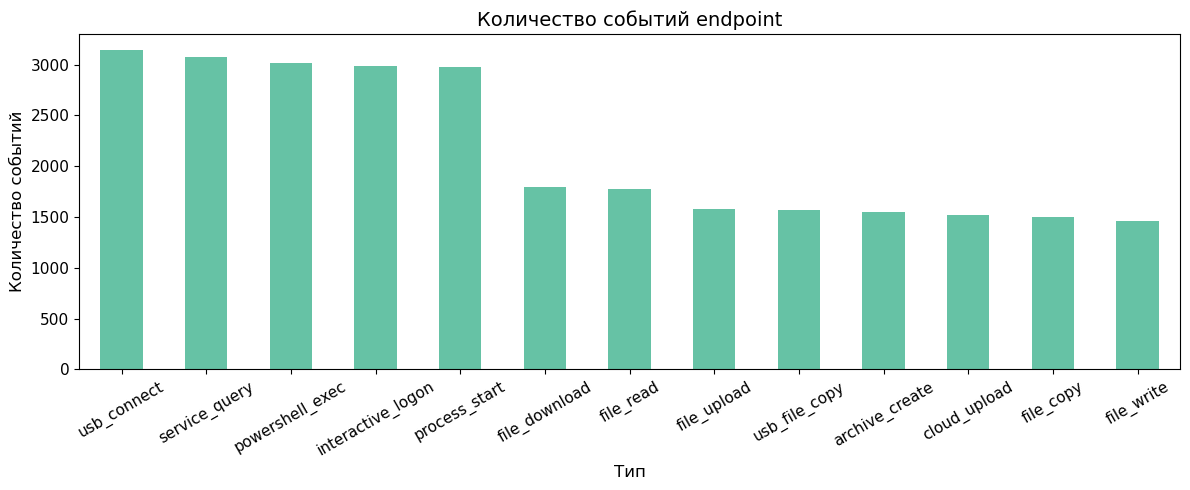

In [156]:
endpoint_df = df[df['log_source'] == 'endpoint']
endpoint_df['event_type'].value_counts().plot(kind='bar', figsize=(12, 5), colormap='Set2')

plt.title(f'Количество событий endpoint', fontsize=14)
plt.xlabel('Тип', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.xticks(fontsize=11, rotation=30)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

## 1.3.3. network

In [161]:
network_df = df[df['log_source'] == 'network']
internal = network_df['destination_ip'].astype(str).str.startswith('10.')
external = ~internal

print('Соотношение внутреннего и внешнего трафика:')
print(f"Внутренний трафик: {internal.sum()}")
print(f"Внешний трафик: {external.sum()}")

Соотношение внутреннего и внешнего трафика:
Внутренний трафик: 49330
Внешний трафик: 40626


### Самые частые внешние IP:

In [163]:
external_ips = df[~df['destination_ip'].astype(str).str.startswith('10.')]
top_external = external_ips['destination_ip'].value_counts().head(5)
print("Топ-5 внешних IP:")
print(top_external)

Топ-5 внешних IP:
destination_ip
104.211.30.1      1695
52.168.138.145    1665
40.77.226.250     1665
20.38.98.100      1663
212.13.197.231    1661
Name: count, dtype: int64


Топ внешних IP относится к Microsoft Azure


# 2. Поиск подозрительной активности

In [34]:
def find_event_sequence_flexible(df, sequence, time_window_minutes=30, same_user=True, same_host=False):
    """
    Универсальная функция для поиска последовательностей событий
    """
    df_copy = df.copy()
    df_copy['timestamp'] = pd.to_datetime(df_copy['timestamp'])
    
    results = []
    
    if same_user:
        user_groups = df_copy.groupby('user_id')
    else:
        user_groups = [('all', df_copy)]
    
    for user_id, user_df in user_groups:
        # первое событие
        first_events = user_df[user_df['log_source'] == sequence[0]['log_source']]
        if 'event_type' in sequence[0] and sequence[0]['event_type']:
            first_events = first_events[first_events['event_type'] == sequence[0]['event_type']]
        
        for idx, first_event in first_events.iterrows():
            start_time = first_event['timestamp']
            end_time = start_time + pd.Timedelta(minutes=time_window_minutes)
            
            # второе событие в окне
            mask = (user_df['timestamp'] >= start_time) & (user_df['timestamp'] <= end_time)
            
            if 'log_source' in sequence[1]:
                mask &= (user_df['log_source'] == sequence[1]['log_source'])
            if 'event_type' in sequence[1] and sequence[1]['event_type']:
                mask &= (user_df['event_type'] == sequence[1]['event_type'])
            
            if same_host:
                mask &= (user_df['hostname'] == first_event['hostname'])
            
            second_events = user_df[mask].sort_values('timestamp')
            
            if not second_events.empty:
                second_event = second_events.iloc[0]
                
                results.append({
                    'user_id': user_id,
                    'hostname': first_event['hostname'],
                    'first_event': f"{first_event['log_source']}:{first_event['event_type']}",
                    'first_time': first_event['timestamp'],
                    'second_event': f"{second_event['log_source']}:{second_event['event_type']}",
                    'second_time': second_event['timestamp'],
                    'time_gap_minutes': (second_event['timestamp'] - first_event['timestamp']).total_seconds() / 60,
                    'destination_ip': second_event.get('destination_ip', 'unknown'),
                    'bytes_sent': second_event.get('bytes_sent', 0)
                })
    
    return pd.DataFrame(results)

## 2.1. Создание архива -> сетевая активность

In [42]:
archive_network_results = find_event_sequence_flexible(
    df, 
    [
        {'log_source': 'endpoint', 'event_type': 'archive_create'},
        {'log_source': 'network', 'event_type': None}
    ],
    time_window_minutes=30,
    same_user=True,
    same_host=False
)

external_archive_results = archive_network_results[~archive_network_results['destination_ip'].astype(str).str.startswith('10.')]

external_archive_results['is_night'] = external_archive_results['first_time'].dt.hour.between(22, 6)
external_archive_results['bytes_mb'] = external_archive_results['bytes_sent'] / (1024 * 1024)
sorted_by_volume = external_archive_results.sort_values('bytes_sent', ascending=False)

sorted_by_volume.head(5)


/tmp/ipykernel_3901831/468440555.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  external_archive_results['is_night'] = external_archive_results['first_time'].dt.hour.between(22, 6)
/tmp/ipykernel_3901831/468440555.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  external_archive_results['bytes_mb'] = external_archive_results['bytes_sent'] / (1024 * 1024)


,user_id,hostname,first_event,first_time,second_event,second_time,time_gap_minutes,destination_ip,bytes_sent,is_night,bytes_mb
849,U0056,WS-RND-056,endpoint:archive_create,2025-05-29 19:41:46,network:nan,2025-05-29 19:44:38,2.866667,104.18.32.155,6.428849e+09,False,6131.028268
848,U0056,WS-RND-056,endpoint:archive_create,2025-05-29 19:39:18,network:nan,2025-05-29 19:44:38,5.333333,104.18.32.155,6.428849e+09,False,6131.028268
1062,U0073,WS-RND-073,endpoint:archive_create,2025-05-29 12:16:32,network:nan,2025-05-29 12:17:30,0.966667,172.217.15.99,6.939200e+04,False,0.066177
977,U0064,WS-MKT-064,endpoint:archive_create,2025-05-16 11:10:01,network:nan,2025-05-16 11:18:45,8.733333,13.82.152.48,5.085600e+04,False,0.048500
899,U0058,WS-RND-058,endpoint:archive_create,2025-05-22 11:49:59,network:nan,2025-05-22 12:12:47,22.800000,20.42.24.50,4.387200e+04,False,0.041840


Ключевые признаки:
- Аномально большой объем данных (6.13 GB)
- Внешний IP-адрес
- Время: 19:41 (вечер, нерабочее время для большинства сотрудников)
- Имеет уровень privileged в отделе R&D

Уровень риска - критический

Запрос дополнительных данных у SOC-команды:
- Информация об IP адресе 104.18.32.155
- Логи архива (содержимое)
- Логи файловой системы

## 2.2. Powershell -> внешнее соединение

In [53]:
powershell_network_sequence = [
    {'log_source': 'endpoint', 'event_type': 'powershell_exec'},
    {'log_source': 'network', 'event_type': None}  
]

powershell_results = find_event_sequence_flexible(
    df,
    powershell_network_sequence,
    time_window_minutes=30,
    same_user=True,
    same_host=True
)

powershell_external = powershell_results[
    ~powershell_results['destination_ip'].astype(str).str.startswith('10.')
].copy()

powershell_external.sort_values('bytes_sent', ascending=False).head(5)


,user_id,hostname,first_event,first_time,second_event,second_time,time_gap_minutes,destination_ip,bytes_sent
570,U0019,WS-SUP-019,endpoint:powershell_exec,2025-05-27 09:17:47,network:nan,2025-05-27 09:37:36,19.816667,23.96.64.84,53391.0
625,U0022,WS-IT-022,endpoint:powershell_exec,2025-05-27 10:34:29,network:nan,2025-05-27 10:42:08,7.650000,46.43.34.31,50158.0
1103,U0038,WS-EXE-038,endpoint:powershell_exec,2025-05-16 11:41:04,network:nan,2025-05-16 11:44:20,3.266667,52.239.152.10,44790.0
1105,U0038,WS-EXE-038,endpoint:powershell_exec,2025-05-20 11:37:17,network:nan,2025-05-20 11:39:18,2.016667,134.170.58.123,42318.0
450,U0015,WS-LEG-015,endpoint:powershell_exec,2025-05-27 10:41:59,network:nan,2025-05-27 10:42:17,0.300000,23.96.64.84,34528.0


Эти случаи не похожи на подозрительные, тк
- IP известные (Azure, Microsoft)
- Объем 34-53 KB (маленький)
- Рабочее время

## 2.3. USB-подключение -> копирование файлов

### Особенно подозрительны операции в ночное время или на выходных

In [27]:
def find_insider_usb_activity(endpoint_df):
    """
    Поиск инсайдерской активности: USB подключение -> копирование файлов
    Возвращает только те случаи, которые произошли ночью или в выходные
    """
    results = []
    
    usb_events = endpoint_df[endpoint_df['event_type'] == 'usb_connect'].sort_values('timestamp')
    
    for idx, usb in usb_events.iterrows():
        user = usb['user_id']
        host = usb['hostname']
        usb_time = usb['timestamp']
        end_time = usb_time + pd.Timedelta(minutes=10)
        
        # Ищем операции с файлами после USB
        file_ops = endpoint_df[
            (endpoint_df['user_id'] == user) &
            (endpoint_df['hostname'] == host) &
            (endpoint_df['timestamp'] >= usb_time) &
            (endpoint_df['timestamp'] <= end_time) &
            (endpoint_df['event_type'].isin(['usb_file_copy', 'file_write', 'file_copy']))
        ]
        
        if not file_ops.empty:
            is_night = usb_time.hour < 6 or usb_time.hour > 20 
            is_weekend = usb_time.dayofweek in [5, 6]  # Суббота или Воскресенье
            
            if is_night or is_weekend:
                results.append({
                    'user_id': user,
                    'hostname': host,
                    'usb_time': usb_time,
                    'day_of_week': usb_time.dayofweek,  # 0=Пн, 6=Вс
                    'hour': usb_time.hour,
                    'file_ops': len(file_ops),
                    'file_types': file_ops['event_type'].tolist(),
                    'is_night': is_night,
                    'is_weekend': is_weekend,
                    'risk': 'HIGH' if (is_night and is_weekend) else 'MEDIUM'
                })
    
    return pd.DataFrame(results)


# Применяем
usb_insider = find_insider_usb_activity(df)
usb_insider.head()

,user_id,hostname,usb_time,day_of_week,hour,file_ops,file_types,is_night,is_weekend,risk
0,U0056,WS-RND-056,2025-05-25 18:44:38,6,18,1,[usb_file_copy],False,True,MEDIUM


In [28]:
print(f"   Ночных активностей: {usb_insider['is_night'].sum()}")
print(f"   Активностей в выходные: {usb_insider['is_weekend'].sum()}")
print(f"   Ночью И в выходные: {((usb_insider['is_night']) & (usb_insider['is_weekend'])).sum()}")

# Топ пользователей
top_users = usb_insider['user_id'].value_counts().head(10)
print(f"\nТоп пользователей с подозрительной активностью")
for user, count in top_users.items():
    user_dept = df[df['user_id'] == user]['department'].iloc[0] if not df[df['user_id'] == user].empty else 'unknown'
    print(f"   {user} ({user_dept}): {count} случаев")

   Ночных активностей: 0
   Активностей в выходные: 1
   Ночью И в выходные: 0

Топ пользователей с подозрительной активностью
   U0056 (R&D): 1 случаев


In [30]:
# Детальный анализ U0056 в этот день
user = 'U0056'
date = '2025-05-25'  

user_data = df[df['user_id'] == user]
day_data = user_data[user_data['timestamp'].dt.date == pd.to_datetime(date).date()]

print(f"\nendpoint события:")
endpoint_day = day_data[day_data['log_source'] == 'endpoint']
print(endpoint_day[['timestamp', 'event_type', 'hostname']])

network_day = day_data[day_data['log_source'] == 'network']
external_day = network_day[~network_day['destination_ip'].astype(str).str.startswith('10.')]

if not external_day.empty:
    print(f"\nвнешний трафик:")
    print(external_day[['timestamp', 'destination_ip', 'bytes_sent']])

user_weekdays = user_data[user_data['timestamp'].dt.dayofweek < 5]  
user_weekends = user_data[user_data['timestamp'].dt.dayofweek >= 5]  

print(f"\nсравнение активности:")
print(f"   Будние дни (Пн-Пт): {len(user_weekdays)} событий")
print(f"   Выходные (Сб-Вс): {len(user_weekends)} событий")
print(f"   Доля в выходные: {len(user_weekends) / len(user_data) * 100:.1f}%")

# 5. Проверяем другие USB-активности
usb_events = user_data[user_data['event_type'] == 'usb_connect']
print(f"\n🔌 ВСЕ USB-ПОДКЛЮЧЕНИЯ {user}:")
print(usb_events[['timestamp', 'hostname']])


endpoint события:
                 timestamp      event_type    hostname
104460 2025-05-25 07:18:37  archive_create  WS-RND-056
104629 2025-05-25 09:37:48     usb_connect  WS-RND-056
105014 2025-05-25 12:40:26   file_download  WS-RND-056
105069 2025-05-25 13:16:49   file_download  WS-RND-056
105078 2025-05-25 13:21:30       file_read  WS-RND-056
105141 2025-05-25 14:12:20       file_read  WS-RND-056
105146 2025-05-25 14:19:26   file_download  WS-RND-056
105150 2025-05-25 14:23:24     usb_connect  WS-RND-056
105169 2025-05-25 14:44:45   usb_file_copy  WS-RND-056
105171 2025-05-25 14:47:11       file_read  WS-RND-056
105173 2025-05-25 14:50:08   process_start  WS-RND-056
105185 2025-05-25 15:07:48       file_read  WS-RND-056
105194 2025-05-25 15:31:46       file_read  WS-RND-056
105198 2025-05-25 15:43:50   file_download  WS-RND-056
105200 2025-05-25 15:45:41  archive_create  WS-RND-056
105201 2025-05-25 15:47:38   file_download  WS-RND-056
105202 2025-05-25 15:52:29       file_read  WS

Ключевые признаки:
- Нерабочее время (воскресенье)
- Доля активности в выходные у U0056 составляет всего 6.3% от общего объема, это не его обычный паттерн
- Многократное копирование на USB
- Создание архивов перед копированием
- Высокий уровень привилегий (доступ к интеллектуальной собственности и критическим данным)

Уровень риска - высокий

Запрос дополнительных данных у SOC-команды:
- Логи файловой системы (список скопированных файлов)
- Логи архивации (что было заархивировано перед копированием)
- Логи USB (Был ли USB выдан компанией или это личное устройство)

## 2.4. Неудачный вход -> успешный вход

In [98]:
def find_bruteforce_by_country(
    auth_df, 
    time_window_minutes=30, 
    failed_threshold=3, 
    country_threshold=2,
    ip_threshold=None
):
    """
    Поиск брутфорса: N+ неудачных попыток из разных стран И/ИЛИ разных IP
    """
    results = []
    
    for user in auth_df['user_id'].unique():
        user_auth = auth_df[auth_df['user_id'] == user].sort_values('timestamp').reset_index(drop=True)
        
        if len(user_auth) < failed_threshold + 1:
            continue
        
        i = 0
        while i < len(user_auth):
            if user_auth.loc[i, 'auth_success'] != 0:
                i += 1
                continue
            
            start_time = user_auth.loc[i, 'timestamp']
            end_time = start_time + pd.Timedelta(minutes=time_window_minutes)
            
            failed_mask = (
                (user_auth['timestamp'] >= start_time) &
                (user_auth['timestamp'] <= end_time) &
                (user_auth['auth_success'] == 0)
            )
            failed_events = user_auth[failed_mask]
            
            if len(failed_events) >= failed_threshold:
                unique_countries = failed_events['geo_country'].dropna().nunique()
                unique_ips = failed_events['source_ip'].nunique()
                
                # Проверяем: страны ИЛИ IP
                country_ok = unique_countries >= country_threshold if country_threshold else False
                ip_ok = unique_ips >= ip_threshold if ip_threshold else False
                
                if country_ok or ip_ok:
                    success_mask = (
                        (user_auth['timestamp'] >= start_time) &
                        (user_auth['timestamp'] <= end_time) &
                        (user_auth['auth_success'] == 1)
                    )
                    success_events = user_auth[success_mask]
                    
                    if not success_events.empty:
                        success_event = success_events.iloc[0]
                        
                        results.append({
                            'user_id': user,
                            'failed_count': len(failed_events),
                            'unique_countries': unique_countries,
                            'countries': [c for c in failed_events['geo_country'].unique().tolist() if pd.notna(c)],
                            'unique_ips': unique_ips,
                            'ips': failed_events['source_ip'].unique().tolist(),
                            'start_time': start_time,
                            'success_time': success_event['timestamp'],
                            'time_window_minutes': round((success_event['timestamp'] - start_time).total_seconds() / 60, 1),
                            'source_ip_success': success_event['source_ip'],
                            'geo_country_success': success_event['geo_country']
                        })
                        
                        i = success_event.name + 1
                        continue
            
            i += 1
    
    return pd.DataFrame(results)

find_bruteforce_by_country(
    df, 
    time_window_minutes=30, 
    failed_threshold=3, 
    country_threshold=2,
    ip_threshold=None
)

,user_id,failed_count,unique_countries,countries,unique_ips,ips,start_time,success_time,time_window_minutes,source_ip_success,geo_country_success
0,U0042,34,3,"[RU, US, BG]",4,"[193.27.228.91, 45.155.205.233, 159.203.44.17,...",2025-05-12 20:05:37,2025-05-12 20:32:00,26.4,45.155.205.233,RU


### Обнаружена подозрительная активнсоть! 
Ключевые признаки: 
- количество неудачных попыток входа (34 неудачные попытки за 27 минут)
- входы с разных IP-адресов (4 разных IP-адреса)
- входы из разных стран (RU, US, BG)
- атака завершилась успехом (в 20:32:00 зафиксирован успешный вход)

Уровень риска - критический

Запрос дополнительных данных у SOC-команды:
- Логи активности пользователя U0042 после успешного входа
- Логи изменения пароля

## 2.5. Всплеск активности у пользователя U0017

In [65]:
user = 'U0017'
user_data = df[df['user_id'] == user].copy()

user_info = df[df['user_id'] == user][['department', 'privilege_level']].drop_duplicates()
if not user_info.empty:
    print(f"Информация:")
    print(f"   Отдел: {user_info['department'].iloc[0]}")
    print(f"   Уровень привилегий: {user_info['privilege_level'].iloc[0]}")

spike_start = spike_days.index.min()
spike_end = spike_days.index.max()

spike_data = user_data[
    (user_data['timestamp'].dt.date >= spike_start) & 
    (user_data['timestamp'].dt.date <= spike_end)
].copy() 

print(f"\nДействия пользователя во время всплеска ({spike_start} - {spike_end}):")
print(f"\n   Распределение по источникам:")
print(spike_data['log_source'].value_counts())

network_spike = spike_data[spike_data['log_source'] == 'network'].copy() 

internal_prefixes = ('10.',)
network_spike.loc[:, 'is_internal'] = network_spike['destination_ip'].astype(str).str.startswith(internal_prefixes)  
internal_count = network_spike['is_internal'].sum()
external_count = len(network_spike) - internal_count

internal_bytes = network_spike[network_spike['is_internal']]['bytes_sent'].sum()
external_bytes = network_spike[~network_spike['is_internal']]['bytes_sent'].sum()

print(f"\nАнализ сетевого трафика во время всплеска")
print(f"   Всего network-событий: {len(network_spike)}")
print(f"\n  Внутренний :")
print(f"      Соединений: {internal_count} ({internal_count/len(network_spike)*100:.1f}%)")
print(f"      Объем: {internal_bytes/1024/1024:.2f} MB")
print(f"\n  Внешний:")
print(f"      Соединений: {external_count} ({external_count/len(network_spike)*100:.1f}%)")
print(f"      Объем: {external_bytes/1024/1024:.2f} MB")

Информация:
   Отдел: Engineering
   Уровень привилегий: standard

Действия пользователя во время всплеска (2025-05-19 - 2025-05-22):

   Распределение по источникам:
log_source
network     1343
endpoint      51
auth          50
Name: count, dtype: int64

Анализ сетевого трафика во время всплеска
   Всего network-событий: 1343

  Внутренний :
      Соединений: 101 (7.5%)
      Объем: 0.76 MB

  Внешний:
      Соединений: 1242 (92.5%)
      Объем: 5302.28 MB


### Исходя из EDA с 18 до 22 мая наблюдается всплеск активности пользователя U0017

Ключевые признаки:
- Внезапный рост активности в 3.6 раза
- Резкое начало (19 мая) и резкое окончание (23 мая)
- Аномальное доминирование сетевого трафика (93%)
- Критическое соотношение внешнего/внутреннего трафика (92.5% внешнего)
- powershell_exec (5 раз) - инструмент, используемый в атаках
- cloud_upload (5 раз) - загрузка данных в облачные сервисы
- archive_create (3 раза) - подготовка данных перед отправкой
- usb_file_copy (3 раза) - копирование на внешний носитель
- Отдел Engineering (доступ к чувствительным данным и проектам)

Уровень риска - высокий

Запрос дополнительных данных у SOC-команды:
- Информация о внешних IP-адресах
- Содержимое облачных загрузок
- Содержимое архивов
- Логи Powershell 

## 2.6. Аномальный внешний трафик на хосте

In [97]:
network_df['hour'] = network_df['timestamp'].dt.hour
external = network_df[~network_df['destination_ip'].astype(str).str.startswith('10.')]

host_hour_traffic = external.groupby(['hostname', 'hour'])['bytes_sent'].sum() / (1024 * 1024)
host_hour_traffic = host_hour_traffic.reset_index()
host_hour_traffic.columns = ['hostname', 'hour', 'traffic_mb']

print('Аномальные часы для каждого хоста:')
for host in host_hour_traffic['hostname'].unique():
    host_data = host_hour_traffic[host_hour_traffic['hostname'] == host]
    mean_h = host_data['traffic_mb'].mean()
    std_h = host_data['traffic_mb'].std()
    if std_h > 0:
        threshold_h = mean_h + 3 * std_h
        spikes = host_data[host_data['traffic_mb'] > threshold_h]
        if not spikes.empty:
            print(f"\n{host}:")
            for _, row in spikes.iterrows():
                print(f"  {row['hour']}:00 — {row['traffic_mb']:.1f} MB (среднее: {mean_h:.1f})")

Аномальные часы для каждого хоста:

WS-ENG-017:
  22:00 — 5300.1 MB (среднее: 221.0)

WS-FIN-042:
  21:00 — 880.0 MB (среднее: 67.9)


### Для хоста WS-ENG-017:

Ключевые признаки:
- Внезапный всплеск трафика в 24 раза выше среднего
- Время: 22:00 (нерабочее время для большинства сотрудников)
- Единовременный выброс (в один час, только на одном хосте)
- Engineering - отдел с доступом к исходному коду и проектам

Уровень риска - критический

Запрос дополнительных данных у SOC-команды:
- Какой пользователь был на хосте WS-ENG-017 в 22:00
- Куда именно уходил трафик
- История хоста (были ли ранее такие выбросы)

# 3. Система детектирования

## 3.1. Обнаружение брутфорса по неудачным входам из разных стран

### Правило выявляет автоматизированный подбор паролей (брутфорс) по следующим признакам:
1.  Один пользователь совершает 3 и более неудачных попытки входа в течение 30 минут
2. Неудачные попытки приходят из 2 и более разных стран (по geo_country)
3. Фиксируется как сам факт атаки, так и случай, когда атака завершилась успешным входом

### Обоснование: 

Обычный пользователь редко ошибается в пароле более 2-3 раз подряд. 
Если ошибки происходят из разных стран - это почти всегда автоматизированная атака с использованием VPN/прокси или ботнета.

### Пример кода: 
функция find_bruteforce_by_country() из пункта 2.4.

### Возможные ложноположительные срабатывания (FP):

1. Сотрудник использует VPN, VPN может менять страну выхода при каждом подключении. Как обойти:	проверить историю - если пользователь всегда использует VPN, это норма
2. Сотрудник в командировке, вход из другой страны - легитимная ситуация. Как обойти: сверить с HR-данными о командировках
3. Сотрудник с несколькими устройствами: ноутбук, телефон, планшет - разные IP и geo. Как обойти: проверить временные метки. Если попытки идут одновременно - это атака
4. Сбой в геолокации - базы GeoIP могут ошибаться. Как обойти: проверить IP-адреса вручную.

###  Улучшения: 
Добавить проверку на принадлежность IP к корпоративному VPN-пулу, облачным провайдерам и историю командировок.

## 3.2. Обнаружение всплеска внешнего трафика (утечка данных)

### Правило выявляет аномальные всплески внешнего сетевого трафика по следующим критериям:
1. Для каждого хоста вычисляется средний объем внешнего трафика в час за все дни
2.  Если в какой-то час объем трафика превышает среднее + 3 стандартных отклонения - фиксируется аномалия
3. Дополнительно проверяется, что трафик идет на внешние IP (не 10.0.0.0/8)

### Обоснование: 
Резкий всплеск внешнего трафика в нехарактерное время (ночь, вечер, выходные) может указывать на утечку данных, отправку архивов или загрузку в облачные сервисы.

### Пример кода: 
функция host_hour_traffic() из пункта 2.6.

### Возможные ложноположительные срабатывания (FP):

1. Плановый бэкап в облако - большой объем трафика уходит на внешний IP регулярно. Проверить расписание бэкапов, если трафик повторяется ежедневно - это норма
2. Обновление ПО - скачивание больших обновлений. Проверить IP назначения.
3. Загрузка Docker-образов. Проверить отдел: если R&D/Engineering - вероятно, норма.
4. Ночная загрузка отчетов. Проверить регулярность - если каждый день в одно время - это норма

### Улучшения:
Добавить белый список легитимных внешних IP и проверить регулярность всплесков.

## 3.3. Обнаружение активности инсайдера (USB + копирование в нерабочее время)

### Правило выявляет подозрительную активность с USB-накопителями по следующим признакам:
1. Пользователь подключает USB-устройство (usb_connect)
2. В течение 10 минут после подключения происходит копирование файлов (usb_file_copy, file_write, file_copy)
3. Событие происходит в нерабочее время: ночь (0-6) или выходные (суббота, воскресенье)

### Обоснование: 
Копирование данных на USB в нерабочее время - классический паттерн передачи данных третьим лицам. Сотрудники редко копируют большие объемы данных на флешки в выходные дни.

### Пример кода: 
функция find_insider_usb_activity() из пункта 2.3.

### Возможные ложноположительные срабатывания (FP):

1. Сотрудник работает по выходным. Необходимо сверить с HR-данными, графиком работы, историей работы в выходные.
2. Подключение корпоративной флешки. Решение: проверить серийный номер USB в инвентаризации.
3. Копирование рабочих файлов для работы дома. Проверить объем: если файлы мелкие - возможно, норма.
4. Сотрудник работает в ночную смену. Проверить должность и график работы

### Улучшения
Добавить проверку серийных номеров USB, проверить историю работы пользователя в нерабочее время, анализировать объем скопированных данных (мелкие файлы = меньше риск)

## 3.4. Обнаружение цепочки архив -> внешний трафик 

### Правило выявляет подготовку и отправку данных во внешнюю сеть:
1. Пользователь создает архив на своей рабочей станции
2. В течение 60 минут после создания архива фиксируется сетевая активность на внешний IP (не 10.0.0.0/8)
3. Дополнительный признак: если объем отправленных данных превышает 10 MB или время между событиями меньше 5 минут - риск повышается

### Обоснование: 
Создание архива непосредственно перед отправкой данных во внешнюю сеть - классический паттерн утечки. 
Это говорит о том, что пользователь целенаправленно подготовил данные для выгрузки.

### Пример кода: 
функция find_event_sequence_flexible() из пункта 2.1.
[{'log_source': 'endpoint', 'event_type': 'archive_create'},
{'log_source': 'network', 'event_type': None}]

### Возможные ложноположительные срабатывания (FP):

1. Отправка отчетов в облако (бизнес-отчеты регулярно отправляются в облачные хранилища). Проверить IP: известные облачные сервисы - легитимно
2. Отправка больших вложений по email. Проверить destination_ip: если это почтовый сервер - возможно, норма
3. Резервное копирование (бэкап-скрипты создают архивы и отправляют их на удаленный сервер). Проверить регулярность: если каждый день в одно время - это бэкап

### Улучшения:
Добавить белый список внешних IP для легитимных сервисов и проверить регулярность событий.

## 3.5. Обнаружение всплеска активности пользователя

### Правило выявляет резкие изменения в поведении пользователя:
1. Для каждого пользователя вычисляется средняя дневная активность за 30 дней
2. Если в какой-то день активность превышает среднее + 3 стандартных отклонения - фиксируется аномалия
3. Дополнительно проверяется доля сетевого трафика (> 80% от всей активности) - это повышает риск

### Обоснование: 
Внезапный рост активности, особенно если он связан с доминированием сетевых событий, может указывать на автоматизированный процесс или целенаправленную операцию по сбору и выгрузке данных.

### Пример кода: 
Ячейка из пункта 2.5.

### Возможные ложноположительные срабатывания (FP):
1. Сотрудник работает интенсивнее перед дедлайном. Проверить проектные задачи, коммуникацию с руководителем.
2. Системные обновления создают всплеск активности. Проверить типы событий: если это обновления - исключить
3. Плановый аудит или инвентаризация. Проверить должность: если аудитор - возможно, норма

### Улучшения:
Проверять типы событий во время всплеска - если это легитимные рабочие операции, риск ниже. Если доминирует сетевой трафик - риск выше.

# 4. Выявление аномалий

## 4.1. Подготовка фичей

### Аггрегированные признаки на уровне пользователь-день

Все признаки были выбраны на основе реальных аномалий, обнаруженных на этапе поиска подозрительной активности (Задание 2).

Признак total_events позволяет выявлять внезапные всплески активности, как у пользователя U0017, у которого количество событий выросло в 3.6 раза. Признаки external_traffic_mb и external_connections фиксируют утечки данных - например, U0056 отправил 6.13 GB, а U0017 - 5.3 GB во внешнюю сеть, при этом доля сетевого трафика достигала 93%.

Признак archive_count был добавлен, потому что U0056 и U0001 создавали архивы непосредственно перед отправкой данных. Признаки usb_events и usb_file_copies отражают инсайдерскую активность - U0056 подключал USB 4 раза в выходной день и копировал файлы. powershell_count выявляет использование инструмента для атак - U0017 запускал PowerShell 5 раз за день во время всплеска активности.

Признак file_downloads показывает систематический сбор данных: U0056 скачал 246 файлов за месяц, что в 12 раз выше среднего. Признаки failed_logins и unique_countries обнаруживают брутфорс-атаки - U0042 совершил 34 неудачных входа из 3 разных стран за 27 минут.

Таким образом, каждый признак соответствует конкретному типу угрозы, найденной в данных, что позволяет модели DBSCAN автоматически выявлять как уже известные, так и новые аномалии.

In [103]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

df['date'] = df['timestamp'].dt.date

def prepare_features(df):
    # Базовые признаки
    features = df.groupby(['user_id', 'date']).agg(
        total_events=('event_id', 'count'),
        failed_logins=('auth_success', lambda x: (x == 0).sum()),
        unique_countries=('geo_country', lambda x: x.nunique()),
        archive_count=('event_type', lambda x: (x == 'archive_create').sum()),
        usb_events=('event_type', lambda x: (x == 'usb_connect').sum()),
        powershell_count=('event_type', lambda x: (x == 'powershell_exec').sum()),
        file_downloads=('event_type', lambda x: (x == 'file_download').sum()),
        usb_file_copies=('event_type', lambda x: (x == 'usb_file_copy').sum()),
        cloud_uploads=('event_type', lambda x: (x == 'cloud_upload').sum())
    ).reset_index()
    
    # Сетевые признаки (только внешний трафик)
    network_df = df[df['log_source'] == 'network']
    external = network_df[~network_df['destination_ip'].astype(str).str.startswith('10.')]
    
    network_features = external.groupby(['user_id', 'date']).agg(
        external_traffic_mb=('bytes_sent', lambda x: x.sum() / (1024 * 1024)),
        external_connections=('event_id', 'count')
    ).reset_index()
    
    result = features.merge(network_features, on=['user_id', 'date'], how='left').fillna(0)
    
    return result

features_df = prepare_features(df)

print('Подготовленные признаки:')
features_df.head()

Подготовленные признаки:


,user_id,date,total_events,failed_logins,unique_countries,archive_count,usb_events,powershell_count,file_downloads,usb_file_copies,cloud_uploads,external_traffic_mb,external_connections
0,SVC-LEGACY,2025-05-01,1,0,1,0,0,0,0,0,0,0.0,0.0
1,SVC-LEGACY,2025-05-02,1,0,1,0,0,0,0,0,0,0.0,0.0
2,SVC-LEGACY,2025-05-04,1,0,1,0,0,0,0,0,0,0.0,0.0
3,SVC-LEGACY,2025-05-09,1,0,1,0,0,0,0,0,0,0.0,0.0
4,SVC-LEGACY,2025-05-10,3,0,1,0,0,0,0,0,0,0.0,0.0


## 4.2. Шкалирование данных

In [109]:
feature_columns = [
    'total_events',
    'external_traffic_mb',
    'external_connections',
    'archive_count',
    'usb_events',
    'powershell_count',
    'file_downloads',
    'usb_file_copies',
    'cloud_uploads',
    'failed_logins',
    'unique_countries'
]

X = features_df[feature_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4.3. Подбор оптимального eps методом локтя:

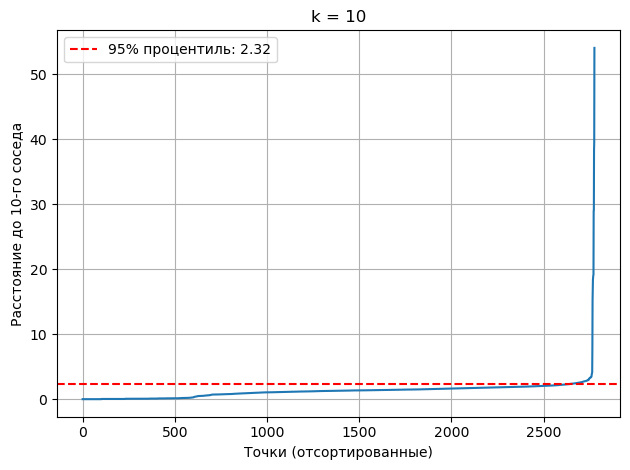

 90-й процентиль: 2.028
 95-й процентиль: 2.317
 95-й процентиль: 3.149


In [130]:
from sklearn.neighbors import NearestNeighbors
    
k = 10
neigh = NearestNeighbors(n_neighbors=k)
neigh_fit = neigh.fit(X_scaled)
distances, indices = neigh_fit.kneighbors(X_scaled)

k_distances = distances[:, k-1]

k_distances_sorted = np.sort(k_distances, axis=0)

plt.plot(k_distances_sorted)
plt.xlabel('Точки (отсортированные)')
plt.ylabel(f'Расстояние до {k}-го соседа')
plt.title(f'k = {k}')
plt.grid(True)

# Находим точку локтя
# 95-й процентиль как запас
eps_candidate = np.percentile(k_distances, 95)
plt.axhline(y=eps_candidate, color='red', linestyle='--', 
           label=f'95% процентиль: {eps_candidate:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f" 90-й процентиль: {np.percentile(k_distances, 90):.3f}")
print(f" 95-й процентиль: {np.percentile(k_distances, 95):.3f}")
print(f" 95-й процентиль: {np.percentile(k_distances, 99):.3f}")

## 4.4. Кластеризация DBSCAN

DBSCAN хорошо подходит для этой задачи, потому что:
- Он находит кластеры нормального поведения и точки-выбросы (аномалии)
- Не требует предположений о распределении данных
- Имеет четкую интерпретацию: "событие не похоже ни на что другое"
- Хорошо работает с многомерными данными 

In [137]:
# DBSCAN
dbscan = DBSCAN(eps=2.45, min_samples=10) # радиус окрестности, минимальное количество точек для кластера
labels = dbscan.fit_predict(X_scaled)

# 4. Добавляем метки в DataFrame
features_df['cluster'] = labels
# -1 = аномалия (шум)
features_df['is_anomaly'] = features_df['cluster'] == -1

anomalies = features_df[features_df['is_anomaly']]

print(f"Кластеров найдено: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Аномалий: {features_df['is_anomaly'].sum()}")
print(f"Доля аномалий: {features_df['is_anomaly'].sum() / len(features_df) * 100:.2f}%")

Кластеров найдено: 1
Аномалий: 30
Доля аномалий: 1.08%


## 4.5. Визуализация

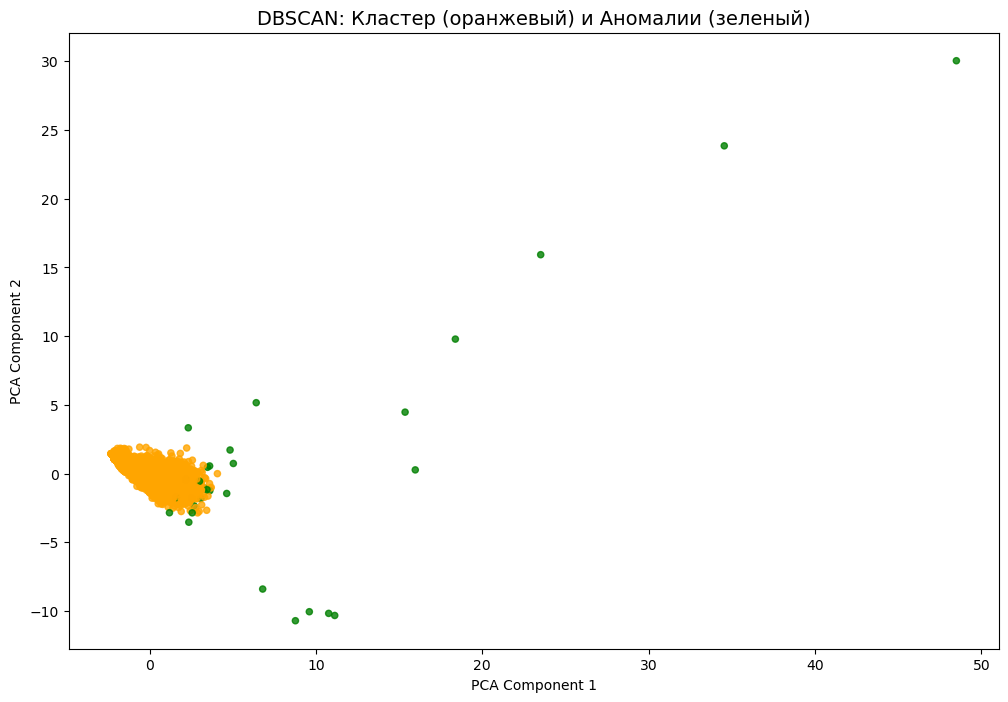

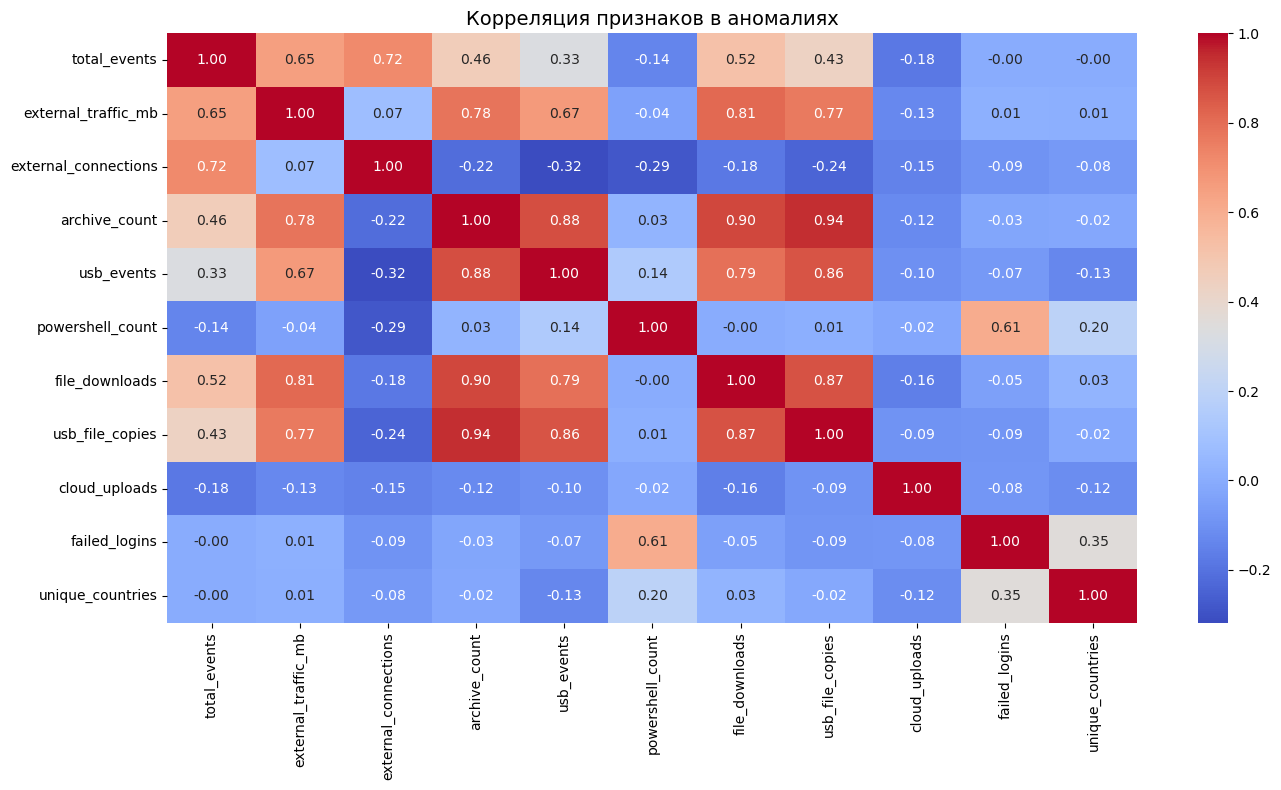

In [140]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
colors = ['orange' if label != -1 else 'green' for label in labels]
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.8, s=20)
plt.title('DBSCAN: Кластер (оранжевый) и Аномалии (зеленый)', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

# Тепловая карта признаков для аномалий
anomaly_features = anomalies[feature_columns]
plt.figure(figsize=(14, 8))
sns.heatmap(anomaly_features.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция признаков в аномалиях', fontsize=14)
plt.tight_layout()
plt.show()

## 4.6. Аномальные события

In [144]:
anomalies = features_df[features_df['is_anomaly']].copy()

print(f"Всего аномалий: {len(anomalies)}")

# сортировка по объему внешнего траффика и информации по отделу
anomalies_sorted = anomalies.sort_values('external_traffic_mb', ascending=False)

user_info = df[['user_id', 'department', 'privilege_level']].drop_duplicates('user_id')
anomalies_sorted = anomalies_sorted.merge(user_info, on='user_id', how='left')

def get_anomaly_reasons(row):
    reasons = []
    
    # 1. Внешний трафик
    if row['external_traffic_mb'] > 100:
        reasons.append(f"Внешний трафик: {row['external_traffic_mb']:.1f} MB")
    
    # 2. Архивы
    if row['archive_count'] > 2:
        reasons.append(f"Создание архивов: {row['archive_count']}")
    
    # 3. USB
    if row['usb_file_copies'] > 2:
        reasons.append(f"Копирование на USB: {row['usb_file_copies']}")
    
    # 4. PowerShell
    if row['powershell_count'] > 2:
        reasons.append(f"PowerShell: {row['powershell_count']}")
    
    # 5. Облако
    if row['cloud_uploads'] > 2:
        reasons.append(f"Загрузка в облако: {row['cloud_uploads']}")
    
    # 6. Скачивания
    if row['file_downloads'] > 10:
        reasons.append(f"Скачивания: {row['file_downloads']}")
    
    # 7. Неудачные входы
    if row['failed_logins'] > 5:
        reasons.append(f"Неудачные входы: {row['failed_logins']}")
    
    # 8. Разные страны
    if row['unique_countries'] > 2:
        reasons.append(f"Стран входа: {row['unique_countries']}")
    
    # 9. Аномально много событий
    if row['total_events'] > 200:
        reasons.append(f"Всего событий: {row['total_events']}")
    
    return ', '.join(reasons) if reasons else 'Комбинация признаков'

anomalies_sorted['anomaly_reasons'] = anomalies_sorted.apply(get_anomaly_reasons, axis=1)
anomalies_sorted.head(5)

Всего аномалий: 30


,user_id,date,total_events,failed_logins,unique_countries,archive_count,usb_events,powershell_count,file_downloads,usb_file_copies,cloud_uploads,external_traffic_mb,external_connections,cluster,is_anomaly,department,privilege_level,anomaly_reasons
0,U0056,2025-05-30,436,2,2,23,22,3,61,21,2,8086.551831,44.0,-1,True,R&D,privileged,"Внешний трафик: 8086.6 MB, Создание архивов: 2..."
1,U0056,2025-05-29,348,0,2,12,14,2,56,14,1,6131.157046,31.0,-1,True,R&D,privileged,"Внешний трафик: 6131.2 MB, Создание архивов: 1..."
2,U0017,2025-05-22,359,0,2,1,0,0,0,1,0,5300.565621,315.0,-1,True,Engineering,standard,"Внешний трафик: 5300.6 MB, Всего событий: 359"
3,U0056,2025-05-28,291,2,2,7,5,2,47,6,1,4386.766745,44.0,-1,True,R&D,privileged,"Внешний трафик: 4386.8 MB, Создание архивов: 7..."
4,U0056,2025-05-27,226,1,2,6,10,3,18,10,1,3406.378226,31.0,-1,True,R&D,privileged,"Внешний трафик: 3406.4 MB, Создание архивов: 6..."


In [146]:
print("\nУглубленный анализ топ-5 аномалий")

for i, (idx, row) in enumerate(anomalies_sorted.head(5).iterrows(), 1):
    print(f"\n{i}. {row['user_id']} ({row['department']}) - {row['date']}")
    print(f"   Детали:")
    print(f"      • Всего событий: {row['total_events']}")
    print(f"      • Внешний трафик: {row['external_traffic_mb']:.1f} MB")
    print(f"      • Внешних соединений: {row['external_connections']}")
    print(f"      • Архивов: {row['archive_count']}")
    print(f"      • USB-подключений: {row['usb_events']}")
    print(f"      • Копирований на USB: {row['usb_file_copies']}")
    print(f"      • PowerShell: {row['powershell_count']}")
    print(f"      • Загрузок в облако: {row['cloud_uploads']}")
    print(f"      • Скачиваний: {row['file_downloads']}")
    print(f"      • Неудачных входов: {row['failed_logins']}")
    print(f"      • Стран входа: {row['unique_countries']}")


Углубленный анализ топ-5 аномалий

1. U0056 (R&D) - 2025-05-30
   Детали:
      • Всего событий: 436
      • Внешний трафик: 8086.6 MB
      • Внешних соединений: 44.0
      • Архивов: 23
      • USB-подключений: 22
      • Копирований на USB: 21
      • PowerShell: 3
      • Загрузок в облако: 2
      • Скачиваний: 61
      • Неудачных входов: 2
      • Стран входа: 2

2. U0056 (R&D) - 2025-05-29
   Детали:
      • Всего событий: 348
      • Внешний трафик: 6131.2 MB
      • Внешних соединений: 31.0
      • Архивов: 12
      • USB-подключений: 14
      • Копирований на USB: 14
      • PowerShell: 2
      • Загрузок в облако: 1
      • Скачиваний: 56
      • Неудачных входов: 0
      • Стран входа: 2

3. U0017 (Engineering) - 2025-05-22
   Детали:
      • Всего событий: 359
      • Внешний трафик: 5300.6 MB
      • Внешних соединений: 315.0
      • Архивов: 1
      • USB-подключений: 0
      • Копирований на USB: 1
      • PowerShell: 0
      • Загрузок в облако: 0
      • Скачиваний:

### С помощью модели DBSCAN были обнаружены те же аномалии, что и при поиске подозрительной активности в пункте 2 (user_id U0056 и U0017)

### В качестве перспективы можно рассмотреть возможность построения отдельных моделей для каждого отдела, чтобы учитывать специфику работы каждго департамента